# Assignment 2: Empirical Properties of Brownian Motion

**Objective:** This notebook empirically verifies two foundational properties of standard Brownian motion (the Wiener process): the convergence of quadratic variation and the divergence of total variation. These properties illustrate why stochastic calculus requires specialized frameworks (like Itô's Lemma) distinct from classical Newtonian calculus when modeling continuous-time asset prices.

**Theoretical Setup:** Let $W_t$ be a standard Brownian motion on the interval $t \in [0, 1]$. We discretize the time interval into $n$ equal steps of size $\Delta t = 1/n$. 
The increments $\Delta W_k = W_{t_k} - W_{t_{k-1}}$ are independent and identically distributed as:
$$\Delta W_k \sim \mathcal{N}(0, \Delta t)$$

We define the discrete approximations for the variations as follows:
* **Quadratic Variation:** $\sum_{k=1}^{n} (\Delta W_k)^2 \xrightarrow{p} t$ (which is $1$ in this interval).
* **Total Variation:** $\sum_{k=1}^{n} |\Delta W_k| \to \infty$. 


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# Global Simulation Parameters
np.random.seed(42)  # Fixed seed for reproducibility
num_paths = 1000
T = 1.0
n_values = [100, 1000, 10000]

---
### Part (a): Path Generation and Quadratic Variation Distributions

**Theoretical Setup:**
We partition the time interval $[0, 1]$ into $n$ equal segments of size $\Delta t = 1/n$. 
We generate the Brownian paths by simulating standard normal increments and computing their cumulative sum:
$$W_{t_k} = \sum_{i=1}^{k} \Delta W_i \quad \text{where} \quad \Delta W_i \sim \mathcal{N}(0, \Delta t)$$

Once the discrete paths are generated, we reconstruct the empirical increments and compute the sum of the squared increments for each path:
$$\text{QV}_n = \sum_{k=1}^{n} (\Delta W_k)^2$$
We plot the distribution of these sums across 1,000 paths for varying resolutions $n \in \{100, 1000, 10000\}$.

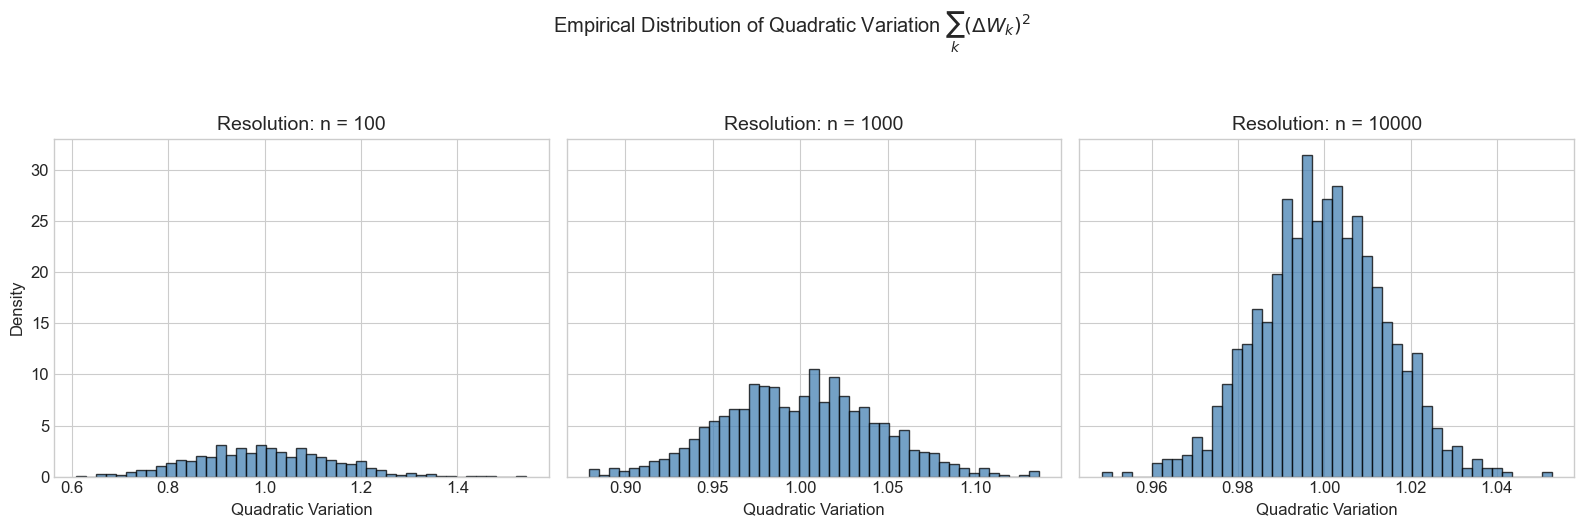

In [55]:
# Dictionaries to store statistical moments for Part (b)
qv_means = {}
qv_stds = {}

# Setup visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(r'Empirical Distribution of Quadratic Variation $\sum_{k} (\Delta W_k)^2$', y=1.05)

for i, n in enumerate(n_values):
    dt = T / n
    
    # 1. Generating standard normal variables and scale by sqrt(dt)
    dW_theoretical = np.random.randn(num_paths, n) * np.sqrt(dt)
    
    # 2. Generating the explicit Brownian paths using cumsum (as directed)
    W = np.cumsum(dW_theoretical, axis=1)
    
    # 3. Prepending W_0 = 0 to establish the initial state for all paths
    W_initial = np.zeros((num_paths, 1))
    W_full = np.hstack((W_initial, W))
    
    # 4. Extract empirical increments strictly from the realized paths
    empirical_increments = np.diff(W_full, axis=1)
    
    # 5. Compute Quadratic Variation
    QV = np.sum(empirical_increments**2, axis=1)
    
    # Store statistics for later analysis
    qv_means[n] = np.mean(QV)
    qv_stds[n] = np.std(QV)
    
    # Plot histogram
    axes[i].hist(QV, bins=45, density=True, alpha=0.75, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Resolution: n = {n}')
    axes[i].set_xlabel('Quadratic Variation')

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()

---
### Part (b): Statistical Concentration of Quadratic Variation

**Theoretical Expectation:**
The quadratic variation of a standard Brownian motion over $[0, t]$ is precisely $t$. Because our interval is $T=1$, the expected value of the sum is exactly $1$. 

As $n \to \infty$, the Strong Law of Large Numbers dictates that the variance of this sum collapses toward zero. Consequently, the histogram visually narrows, and the probability measure concentrates entirely at $1$. We verify this numerically below.

In [59]:
print("--- Part (b): Statistical Concentration ---")
print(f"{'Resolution (n)':<16} | {'Sample Mean':<14} | {'Sample Std Dev':<14}")
print("-" * 50)

# Retrieve and displaying the statistics computed in Part (a)
for n in n_values:
    print(f"{n:<16} | {qv_means[n]:<14.5f} | {qv_stds[n]:<14.5f}")

# Formal validation check
assert np.isclose(qv_means[10000], 1.0, atol=0.015), "Mean failed to converge within specified bounds."

--- Part (b): Statistical Concentration ---
Resolution (n)   | Sample Mean    | Sample Std Dev
--------------------------------------------------
100              | 1.00102        | 0.14413       
1000             | 0.99969        | 0.04433       
10000            | 0.99961        | 0.01444       


---
### Part (c): Divergence of Total Variation

**Theoretical Expectation:**
The total variation (TV) is defined as the sum of the absolute increments:
$$\text{TV}_n = \sum_{k=1}^{n} |\Delta W_k|$$

Because $\Delta W_k \sim \mathcal{N}(0, \Delta t)$, the expectation of the absolute increment is:
$$\mathbb{E}[|\Delta W_k|] = \sqrt{\frac{2\Delta t}{\pi}}$$
Substituting $\Delta t = 1/n$, the expected total variation across the entire path scales proportionally to $\sqrt{n}$:
$$\mathbb{E}[\text{TV}_n] = n \cdot \sqrt{\frac{2}{n\pi}} = \sqrt{\frac{2n}{\pi}}$$

We will verify this scaling law empirically at $n = 10000$.

In [60]:
n_tv = 10000
dt_tv = T / n_tv

# Generating increments and paths for n = 10000
dW_tv = np.random.randn(num_paths, n_tv) * np.sqrt(dt_tv)
W_tv = np.cumsum(dW_tv, axis=1)

# Extracting empirical increments
W_full_tv = np.hstack((np.zeros((num_paths, 1)), W_tv))
empirical_increments_tv = np.diff(W_full_tv, axis=1)

# Computing Total Variation
TV = np.sum(np.abs(empirical_increments_tv), axis=1)

# Computing ensemble mean
empirical_mean_tv = np.mean(TV)
theoretical_mean_tv = np.sqrt(2 * n_tv / np.pi)

print(f"--- Part (c): Total Variation Analysis at n = {n_tv} ---")
print(f"Empirical Ensemble Mean TV : {empirical_mean_tv:.3f}")
print(f"Theoretical Expected TV    : {theoretical_mean_tv:.3f}")

# Self-Check Verification (as specified in the assignment prompt)
print("\n--- Self-Check Verification ---")
print(f"QV Check (1.00 ± 0.015): {qv_means[10000]:.4f} (Pass: {abs(qv_means[10000] - 1.0) <= 0.015})")
print(f"TV Check (≈ 79.8):       {empirical_mean_tv:.2f} (Pass: {abs(empirical_mean_tv - 79.8) <= 0.5})")

--- Part (c): Total Variation Analysis at n = 10000 ---
Empirical Ensemble Mean TV : 79.795
Theoretical Expected TV    : 79.788

--- Self-Check Verification ---
QV Check (1.00 ± 0.015): 0.9996 (Pass: True)
TV Check (≈ 79.8):       79.80 (Pass: True)
